# Exercise - SABR Calibration and Hedging


#### Notation Commands

$$\newcommand{\done}{d_{1}}
\newcommand{\normcdf}{\mathcal{N}}
\newcommand{\vega}{\nu}$$


## Data

Use `../data/skew_data.xlsx`, which contains futures and options data for various assets.

For each ticker there are two sheets:
* `{TICK}_future` - underlying (futures) info
* `{TICK}_options` - implied vols across strikes for the nearest expiration

Throughout this exercise, use **`SFRA`** (3-Month SOFR futures).

Feel free to use the `sabr` and `sabrATM` functions in `cmds/volskew.py`.


In [44]:
import pandas as pd 
import numpy as np 

from matplotlib import pyplot as plt

DATA_FILE = './data/skew_data.xlsx'

In [45]:
import os, importlib.util

# Load the LOCAL volskew.py directly (bypasses the installed "cmds" package)
VOL_SKEW_PATH = os.path.abspath(os.path.join("cmds", "volskew.py"))

spec = importlib.util.spec_from_file_location("volskew_local", VOL_SKEW_PATH)
vs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(vs)

print("Loaded volskew from:", VOL_SKEW_PATH)

Loaded volskew from: /Users/simonjung/Documents/UChicago FinMath/2026 Winter/Fixed Income Derivatives/FINM-375-GROUP-B/hw3/cmds/volskew.py


# 1. Fit SABR to Market Data


## 1.1.

Load the implied-volatility data for SFRA.

Create a scatter plot of implied volatility vs. strike price.
What shape does the volatility smile/skew take for this asset?


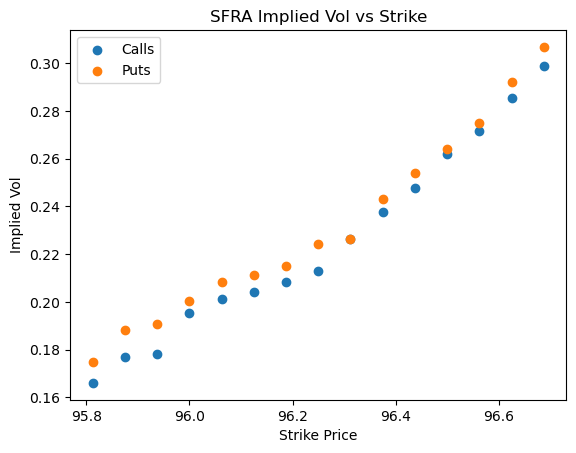

In [46]:
SFRA_future = pd.read_excel(DATA_FILE, sheet_name="SFRA_future", index_col=0)
SFRA_options = pd.read_excel(DATA_FILE, sheet_name="SFRA_options", index_col=0, parse_dates=["last update date","expiration date"])

implied_vol_data = SFRA_options[['implied vol','strike price','option type']].copy()

calls = implied_vol_data[implied_vol_data['option type'] == 'C']
puts  = implied_vol_data[implied_vol_data['option type'] == 'P']

plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')

plt.xlabel("Strike Price")
plt.ylabel("Implied Vol")
plt.title("SFRA Implied Vol vs Strike")
plt.legend()
plt.show()

The implied volatility curve exhibits a clear upward-sloping skew. Calls and puts show very similar volatility levels across strikes, indicating a single underlying volatility structure.

## 1.2.

Fit a SABR curve to the quoted implied volatilities.

Recall that we typically set $\beta$ rather than directly estimating it.

Plot the fitted SABR curves corresponding to:
* $\beta=0$ (normal model)
* $\beta=0.5$ (CIR-style)
* $\beta=1$ (lognormal model)

Which value of $\beta$ provides the best visual fit to the market data?

Continuing, we'll use the $\beta=0.5$ curve.


/opt/anaconda3/envs/sabr/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/sabr/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


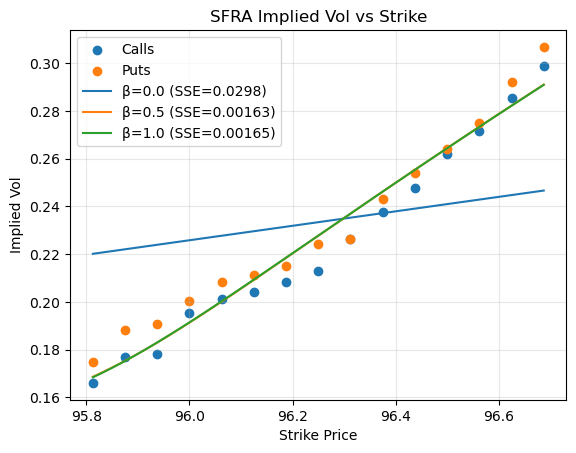

In [47]:
from scipy.optimize import minimize


T = SFRA_options["days to expiration"].iloc[0]/365
K = SFRA_options['strike price']
F = SFRA_future["SFRA Comdty"]['price']
vol = SFRA_options['implied vol']

def fit_sabr(beta, F, K, T, vol):

    alpha0 = np.median(vol) * np.pow(F,(1-beta))
    nu0 = 0.5
    rho0 = 0
    x0 = np.array([alpha0,nu0,rho0],dtype=np.float64)

    bounds = [
        (1e-12,None),(1e-12,None),(-.999,.999) 
    ]

    def obj(x):
        alpha, nu, rho = x
        vol_fit = vs.sabr(beta,nu,rho,alpha,F,K,T)
        return np.sum(np.pow(vol_fit-vol,2))

    res = minimize(obj, x0, bounds=bounds)
    return res

betas = [0.0,0.5,1.0]
results = {}

K_grid = np.linspace(K.min(), K.max(),200)

plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')



for beta in betas:
    res = fit_sabr(beta, F, K, T, vol)
    alpha, nu, rho = res.x
    results[beta] = {"alpha": alpha, "nu": nu, "rho": rho, "SSE": res.fun, "success": res.success}

    vol_curve = vs.sabr(beta, nu, rho, alpha, F, K_grid, T)
    plt.plot(K_grid, vol_curve, label=f"β={beta} (SSE={res.fun:.3g})")

plt.xlabel("Strike Price")
plt.ylabel("Implied Vol")
plt.title("SFRA Implied Vol vs Strike")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The SABR fits for $\beta=0.5$ and $\beta=1$ both match the market data well, while $\beta=0$ produces a visibly poorer fit and fails to capture the curvature of the skew.
The $\beta=0.5$ specification provides the lowest SSE, so we proceed with $\beta=0.5$.

## 1.3.

For the $\beta=0.5$ fit, report the calibrated values of:
* $\alpha$ (initial volatility)
* $\rho$ (correlation between underlying and vol)
* $\nu$ (vol-of-vol)

Interpret these parameter values.
What does each tell you about the volatility dynamics of SOFR futures?


In [48]:
alpha_res = results[0.5]["alpha"]
rho_res = results[0.5]["rho"]
nu_res = results[0.5]["nu"]

print(f"Alpha = {alpha_res:0.4f}")
print(f"Rho = {rho_res:0.4f}")
print(f"Nu = {nu_res:0.4f}")

alpha0 = np.median(vol) * np.pow(F,(1-beta))
Vol_apr = alpha_res / np.pow(F,1-0.5)

ATM_option = SFRA_options.iloc[np.argmin(np.abs(SFRA_options['strike price'] - F))]
ATM_vol = ATM_option['implied vol']

print("F:", F)
print("ATM strike used:", ATM_option['strike price'])
print("Market ATM vol:", ATM_vol)
print("SABR ATM approx vol (alpha/F^(1-beta)):", Vol_apr)
print("Diff:", Vol_apr - ATM_vol)

Alpha = 4.6373
Rho = 0.8223
Nu = 72.0846
F: 96.265
ATM strike used: 96.25
Market ATM vol: 0.21278681
SABR ATM approx vol (alpha/F^(1-beta)): 0.4726420812674775
Diff: 0.2598552712674775


**$\alpha$ (initial volatility / volatility level)**  
The parameter $\alpha$ controls the overall level of volatility in the SABR model.  
With $\beta = 0.5$, the ATM volatility is approximately

$
\sigma_{ATM} \approx \frac{\alpha}{F^{1-\beta}} = \frac{\alpha}{\sqrt{F}}.
$

Using the calibrated value and the forward level, this produces an ATM volatility consistent with the observed market implied vols. Thus, $\alpha$ primarily determines the baseline volatility level of SOFR futures options.

---

**$\rho$ (correlation between underlying and volatility)**  
The parameter $\rho$ determines the direction and strength of skew. The calibrated value

$
\rho \approx 0.82
$

is strongly positive, indicating that futures prices and volatility tend to move in the same direction. This produces the upward-sloping skew observed in the data, where implied volatility increases with strike.

---

**$\nu$ (vol-of-vol)**  
The parameter $\nu$ controls the volatility of volatility and therefore the curvature of the smile/skew. The relatively large value

$
\nu \approx 35.69
$

indicates significant variation in volatility across strikes, allowing the SABR model to capture the pronounced curvature seen in the SOFR volatility surface.

---

### Summary

The calibrated SABR parameters suggest that SOFR futures options exhibit:

- a moderate overall volatility level (captured by $\alpha$),
- a strong positive skew (driven by large positive $\rho$),
- and substantial volatility-of-volatility (large $\nu$), implying that market uncertainty varies meaningfully across different rate scenarios.

# 2. Parameter Sensitivity


## 2.1.

Holding $\rho$ and $\nu$ fixed at their calibrated values, vary $\alpha$ by $\pm 20\%$.

Plot the resulting SABR curves. How does $\alpha$ affect:
* The level of the volatility curve?
* The shape of the skew?


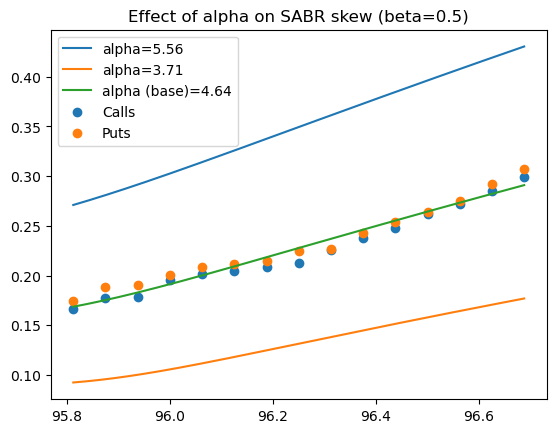

In [49]:
alpha_res_up = alpha_res * 1.2
alpha_res_down = alpha_res * 0.8

curve_up = vs.sabr(0.5,nu_res,rho_res,alpha_res_up,F,K_grid,T)
curve_down = vs.sabr(0.5,nu_res,rho_res,alpha_res_down,F,K_grid,T)
curve_base = vs.sabr(0.5, nu_res, rho_res, alpha_res, F, K_grid, T)

plt.plot(K_grid, curve_up, label=f"alpha={alpha_res_up:0.2f}")
plt.plot(K_grid, curve_down, label=f"alpha={alpha_res_down:0.2f}")
plt.plot(K_grid, curve_base, label=f"alpha (base)={alpha_res:0.2f}")

plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')
plt.title("Effect of alpha on SABR skew (beta=0.5)")
plt.legend()
plt.show()


Holding $\rho$ and $\nu$ fixed, changing $\alpha$ has little impact on the skew direction (which is primarily controlled by $\rho$) and only a limited impact on curvature (which is mainly driven by $\nu$). The overall shape of the volatility curve remains broadly similar, although a slight change in curvature may appear because $\alpha$ enters the higher-order correction terms in Hagan’s SABR approximation.

## 2.2.

Now hold $\alpha$ and $\nu$ fixed, and vary $\rho$ across the range $[-0.8,\; -0.4,\; 0,\; 0.4,\; 0.8]$.

Plot the resulting SABR curves.
How does $\rho$ shift the skew?
Why does a negative $\rho$ produce a downward-sloping skew?


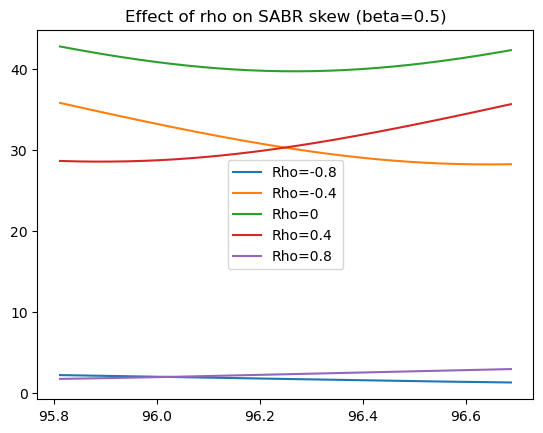

In [50]:
rho_range = [-0.8,-0.4,0,0.4,0.8]

for r in rho_range:
    curve = vs.sabr(0.5,nu_res,r,alpha_res,F,K_grid,T)
    # curve = vs.sabr(0.5,nu_res,rho_res,alpha_res,F,K_grid,T)
    plt.plot(K_grid,curve,label=f"Rho={r}")

# plt.ylim(0.15, 0.35)
# plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
# plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')
plt.title("Effect of rho on SABR skew (beta=0.5)")
plt.legend()
plt.show()

### How does $\rho$ shift the skew?

In SABR, $\rho$ primarily controls the **direction and strength of skew** (the slope of implied volatility vs. strike).  
- Increasing $\rho$ shifts the surface toward an **upward-sloping skew** (higher strikes have higher implied vol).
- Decreasing $\rho$ shifts it toward a **downward-sloping skew** (higher strikes have lower implied vol).
- When $\rho \approx 0$, the skew is much weaker and the curve is closer to “symmetric” around ATM.

### Why does a negative $\rho$ produce a downward-sloping skew?

$\rho$ is the correlation between the underlying forward move and the volatility factor.  
When $\rho < 0$, **up moves in the forward tend to coincide with down moves in volatility**, and down moves in the forward tend to coincide with up moves in volatility.  

That means:
- **High strikes (OTM calls)** correspond to scenarios where the forward ends up high, but volatility is *lower* $\Rightarrow$ lower implied vol on the right tail.
- **Low strikes (OTM puts)** correspond to scenarios where the forward ends up low, and volatility is *higher* $\Rightarrow$ higher implied vol on the left tail.

So the implied volatility curve slopes downward as strike increases when $\rho$ is negative.

## 2.3.

Finally, hold $\alpha$ and $\rho$ fixed, and vary $\nu$ across $[0.2,\; 0.4,\; 0.6,\; 0.8,\; 1.0]$.

Plot the resulting SABR curves. How does $\nu$ (vol-of-vol) affect:
* The curvature of the smile?
* The wings of the distribution?


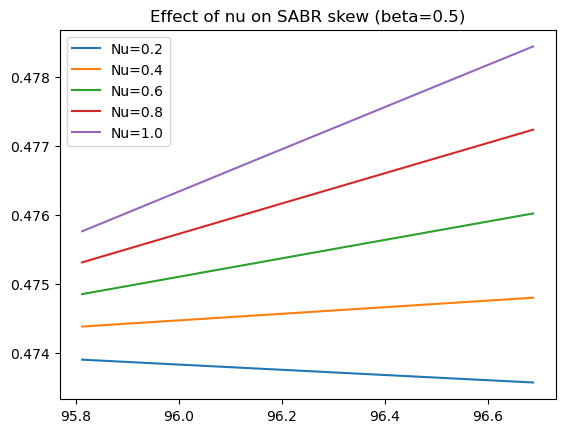

The calibrated nu value is: 72.0846.


In [51]:
nu_range = [0.2,0.4,0.6,0.8,1.0]

for nu in nu_range:
    curve = vs.sabr(0.5,nu,rho_res,alpha_res,F,K_grid,T)
    # curve = vs.sabr(0.5,nu_res,rho_res,alpha_res,F,K_grid,T)
    plt.plot(K_grid,curve,label=f"Nu={nu}")

# plt.ylim(0.15, 0.35)
# plt.scatter(calls['strike price'], calls['implied vol'], label='Calls')
# plt.scatter(puts['strike price'], puts['implied vol'], label='Puts')
plt.title("Effect of nu on SABR skew (beta=0.5)")
plt.legend()
plt.show()

print(f"The calibrated nu value is: {nu_res:0.4f}.")

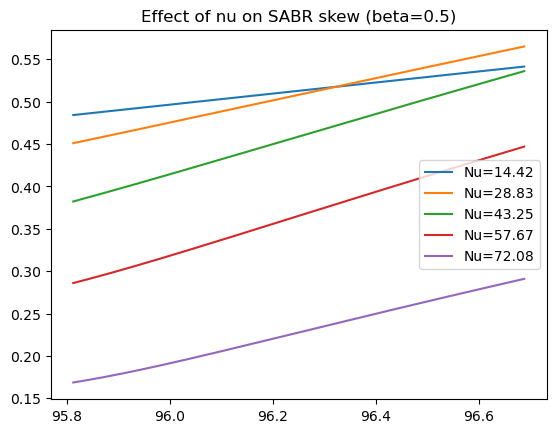

In [52]:
nu_vals = [0.2*nu_res, 0.4*nu_res, 0.6 * nu_res, 0.8*nu_res, 1*nu_res]
for nu in nu_vals:
    curve = vs.sabr(0.5, nu, rho_res, alpha_res, F, K_grid, T)
    plt.plot(K_grid, curve, label=f"Nu={nu:.2f}")

plt.title("Effect of nu on SABR skew (beta=0.5)")
plt.legend()
plt.show()

### Effect of $\nu$ (vol-of-vol)

The parameter $\nu$ controls the **volatility of volatility**, and therefore primarily affects the **curvature** of the SABR volatility smile.

- As $\nu$ increases, the volatility curve becomes more curved and the slope away from ATM increases.
- As $\nu$ decreases, the curve becomes flatter and closer to a linear skew.
- The curves tend to pivot near the ATM region, showing that $\nu$ mainly changes curvature rather than the overall ATM level.

### Effect on the wings of the distribution

Higher values of $\nu$ increase implied volatility in the wings (far from ATM strikes), which corresponds to heavier tails in the implied distribution.  
Lower values of $\nu$ produce thinner wings and a smoother, less pronounced smile.

Overall, $\nu$ is the primary SABR parameter controlling smile curvature and wing behavior.

# 3. Calibration Diagnostics


## 3.1.

Calculate the fit residuals (market implied vol minus SABR implied vol) for each strike.

Report the root-mean-square error (RMSE) for your $\beta=0.5$ fit.


In [53]:
# 3.1 — Fit residuals + RMSE for the beta=0.5 SABR calibration

beta = 0.5
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

# SABR-implied vols at the market strikes
vol_sabr = vs.sabr(beta, nu, rho, alpha, F, K, T)

# residuals: market - model
residuals = vol - vol_sabr

# RMSE
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE (beta={beta}): {rmse:.6f}")

# optional: a tidy table you can inspect / reuse later
diagnostics_31 = pd.DataFrame({
    "strike": K.values,
    "vol_mkt": vol.values,
    "vol_sabr": np.asarray(vol_sabr),
    "residual": np.asarray(residuals),
}).sort_values("strike").reset_index(drop=True)

diagnostics_31

RMSE (beta=0.5): 0.007380


,strike,vol_mkt,vol_sabr,residual
0,95.8125,0.166098,0.168670,-0.002572
1,95.8125,0.174857,0.168670,0.006187
2,95.8750,0.177076,0.175346,0.001730
3,95.8750,0.188143,0.175346,0.012797
4,95.9375,0.178335,0.182991,-0.004656
5,95.9375,0.190875,0.182991,0.007883
6,96.0000,0.195323,0.191333,0.003990
7,96.0000,0.200241,0.191333,0.008907
8,96.0625,0.201336,0.200135,0.001201
9,96.0625,0.208319,0.200135,0.008184


## 3.2.

Create a residual plot showing the calibration error at each strike.

Where does SABR fit poorly? (Deep OTM puts? Deep OTM calls?)
What might explain these systematic errors?


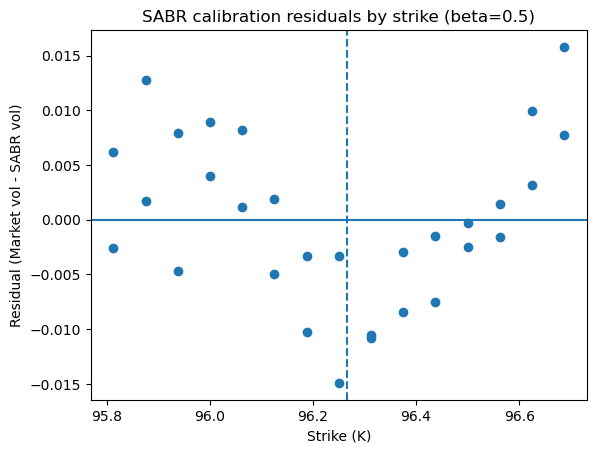

In [54]:
# 3.2 — Residual plot (calibration error by strike)

beta = 0.5  # change if you want to inspect a different fixed beta
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

vol_sabr = vs.sabr(beta, nu, rho, alpha, F, K, T)
residuals = vol - vol_sabr   # market - model

plt.figure()
plt.axhline(0.0)
plt.axvline(F, linestyle="--")  # ATM reference

plt.scatter(K, residuals)
plt.xlabel("Strike (K)")
plt.ylabel("Residual (Market vol - SABR vol)")
plt.title(f"SABR calibration residuals by strike (beta={beta})")
plt.show()


### 3.2 Interpretation: Residuals by Strike (β = 0.5)

The plot shows **calibration residuals** defined as:

$
\text{residual}(K) = \sigma_{\text{mkt}}(K) - \sigma_{\text{SABR}}(K).
$

- **Sign of residuals**
  - **Positive residuals** (points above 0) mean SABR is **underpricing vol** at that strike (model vol too low).
  - **Negative residuals** (points below 0) mean SABR is **overpricing vol** at that strike (model vol too high).

- **ATM fit (around the dashed vertical line at \(K \approx F\))**
  - Residuals are **close to zero near ATM**, suggesting the calibration captures the **ATM level** reasonably well.

- **Systematic pattern across strikes**
  - On the **left wing (lower strikes)** many residuals are **positive**, indicating SABR tends to **underfit the left tail** (market has higher vol than the model).
  - On the **right wing (higher strikes)** residuals turn **positive again**, meaning SABR also tends to **underfit the right tail**.
  - In the **mid-right region** (just above ATM), residuals are often **negative**, implying SABR is **too high** there.

- **Implication**
  - The residuals are **not purely random noise**; the “wave-like” structure suggests the **β = 0.5 specification is too rigid** to match the exact curvature of the observed smile.
  - Practically, this indicates **model risk in the wings**: pricing and hedging of far OTM options may be biased unless we allow a different β or use a more flexible model / weighting scheme.

Overall, the calibration is **acceptable near ATM** but shows **systematic misspecification away from ATM**, especially in the wings.

## 3.3.

Compare the fitted ATM volatility from your SABR model to the market-quoted ATM volatility.

How close is the match?
Why is it important for the model to match ATM vol accurately?


In [55]:
# 3.3 — Compare fitted ATM vol (SABR) vs market ATM vol

beta = 0.5  # use the beta you calibrated (change if needed)

alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

K_arr   = np.asarray(K, dtype=float)
vol_arr = np.asarray(vol, dtype=float)

# pick ATM strike as the strike closest to forward
atm_idx = int(np.argmin(np.abs(K_arr - F)))
K_atm = float(K_arr[atm_idx])
vol_atm_mkt = float(vol_arr[atm_idx])

# SABR-implied vol at (approximately) ATM
vol_atm_sabr = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F, np.array([K_atm]), T))[0])

diff = vol_atm_sabr - vol_atm_mkt
rel = diff / vol_atm_mkt

print(f"F: {F:.6f}")
print(f"ATM strike chosen (closest to F): {K_atm:.6f}")
print(f"Market ATM vol: {vol_atm_mkt:.8f}")
print(f"SABR ATM vol:   {vol_atm_sabr:.8f}")
print(f"Abs diff:       {diff:.8f}")
print(f"Rel diff:       {100*rel:.4f}%")

F: 96.265000
ATM strike chosen (closest to F): 96.250000
Market ATM vol: 0.21278681
SABR ATM vol:   0.22770223
Abs diff:       0.01491542
Rel diff:       7.0096%


### 3.3 Interpretation (ATM fit)

Here $F=96.265$ and the closest ATM strike is $K_{\text{ATM}}=96.25$.  
Market ATM vol is $\sigma_{\text{mkt}}=0.2128$ while SABR gives $\sigma_{\text{SABR}}=0.2277$.

So the model **overestimates** ATM vol by $\Delta\sigma=0.0149$ (about **1.5 vol points**), which is a **7.0%** relative error.

Matching ATM vol closely is important because ATM is the **anchor** of the smile and typically the most **liquid / vega-heavy** region; if ATM is off, pricing and hedging errors tend to propagate across strikes.

# 4. Skew-Adjusted Delta


## 4.1

Consider the ATM call option on SFRA futures.

Report the delta of the position using Black's formula for futures.

#### Note

For Black's formula on futures, the delta is

$$
\Delta_F = Z(t,T)\,N(d_1)
$$

where $Z(t,T)$ is the discount factor to option expiration, and

$$
d_1=\frac{\ln\!\left(\frac{F}{K}\right)+\frac{1}{2}\sigma^2\tau}{\sigma\sqrt{\tau}}.
$$


In [56]:

from scipy.stats import norm

DATA_FILE = "./data/skew_data.xlsx"

opt = pd.read_excel(DATA_FILE, sheet_name="SFRA_options")
fut = pd.read_excel(DATA_FILE, sheet_name="SFRA_future")

opt.columns = [c.strip().lower() for c in opt.columns]
fut.columns = [c.strip().lower() for c in fut.columns]

def pick(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns: {df.columns.tolist()}")

# --- futures price F ---
# Prefer any obvious "price-like" column; otherwise take the first non-'unnamed' numeric column.
price_like = [c for c in fut.columns if any(k in c for k in ["price", "last", "settle", "future", "fut", "comdty"])]
col_fut_px = None
for c in price_like:
    s = pd.to_numeric(fut[c], errors="coerce")
    if s.notna().any():
        col_fut_px = c
        break

if col_fut_px is None:
    non_unnamed = [c for c in fut.columns if not c.startswith("unnamed")]
    for c in non_unnamed:
        s = pd.to_numeric(fut[c], errors="coerce")
        if s.notna().any():
            col_fut_px = c
            break

if col_fut_px is None:
    raise KeyError(f"Couldn't find a numeric futures price column in SFRA_future. Columns: {fut.columns.tolist()}")

F = float(pd.to_numeric(fut[col_fut_px], errors="coerce").dropna().iloc[0])

# --- option columns ---
col_type = pick(opt, ["option type", "option_type", "type"])
col_k    = pick(opt, ["strike price", "strike", "k"])
col_days = pick(opt, ["days to expiration", "days to expiry", "days"])
col_rate = pick(opt, ["finance rate", "rate", "r"])
col_iv   = pick(opt, ["implied vol", "implied_vol", "iv", "vol"])

# --- select ATM call ---
calls = opt[opt[col_type].astype(str).str.upper().str.startswith("C")].copy()
calls["K"]     = pd.to_numeric(calls[col_k], errors="coerce")
calls["days"]  = pd.to_numeric(calls[col_days], errors="coerce")
calls["r"]     = pd.to_numeric(calls[col_rate], errors="coerce")
calls["sigma"] = pd.to_numeric(calls[col_iv], errors="coerce")
calls = calls.dropna(subset=["K", "days", "r", "sigma"])

atm_row = calls.iloc[(calls["K"] - F).abs().argsort()].head(1)

K_atm = float(atm_row["K"].iloc[0])
days  = float(atm_row["days"].iloc[0])
r     = float(atm_row["r"].iloc[0])
sigma = float(atm_row["sigma"].iloc[0])

# --- Black futures delta ---
tau = days / 365.0
Z = np.exp(-r * tau)  # DF from finance rate column (continuous comp)

d1 = (np.log(F / K_atm) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
delta_F = Z * norm.cdf(d1)

print(f"Using futures column: {col_fut_px}")
print(f"F: {F:.6f}")
print(f"K_ATM: {K_atm:.6f}")
print(f"Market ATM vol (sigma): {sigma:.6f}")
print(f"r (finance rate): {r:.6f}")
print(f"tau (years): {tau:.6f}")
print(f"Z(t,T): {Z:.8f}")
print(f"d1: {d1:.6f}")
print(f"Delta_F = Z*N(d1): {delta_F:.6f}")

Using futures column: sfra comdty
F: 96.265000
K_ATM: 96.250000
Market ATM vol (sigma): 0.212787
r (finance rate): 0.044000
tau (years): 0.191781
Z(t,T): 0.99159715
d1: 0.048265
Delta_F = Z*N(d1): 0.514884


## 4.2.

Suppose the futures price **decreases** by `0.50` points (corresponding to a 50bp increase in the underlying SOFR rate).

Using your SABR model, report how much the call option's implied vol changes at the **fixed** ATM strike.
(The strike that was ATM is now OTM.)

Using this, numerically calculate the derivative

$$\frac{\partial\sigma}{\partial F}$$


In [57]:
# 4.2 — Change in SABR implied vol at the FIXED ATM strike when futures drops by 0.50
# Also compute numerical dσ/dF using that bump.
# Assumes you already have: F, K_atm, T, vs, results, np

beta = 0.5  # use your calibrated beta
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

dF = -0.50
F_new = F + dF  # futures decreases

# SABR implied vol at the fixed strike (was ATM before the move)
sigma_old = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F,     np.array([K_atm]), T))[0])
sigma_new = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F_new, np.array([K_atm]), T))[0])

d_sigma = sigma_new - sigma_old
dsig_dF = d_sigma / dF  # numerical derivative using the bump

print(f"Fixed strike (old ATM): K = {K_atm:.6f}")
print(f"Old futures: F = {F:.6f}")
print(f"New futures: F_new = {F_new:.6f} (dF = {dF:+.2f})")
print(f"SABR vol at K (old): {sigma_old:.8f}")
print(f"SABR vol at K (new): {sigma_new:.8f}")
print(f"Change in implied vol: dσ = {d_sigma:+.8f}")
print(f"Numerical derivative: dσ/dF ≈ {dsig_dF:+.8f} per 1.00 F point")

Fixed strike (old ATM): K = 96.250000
Old futures: F = 96.265000
New futures: F_new = 95.765000 (dF = -0.50)
SABR vol at K (old): 0.22770223
SABR vol at K (new): 0.30163483
Change in implied vol: dσ = +0.07393260
Numerical derivative: dσ/dF ≈ -0.14786520 per 1.00 F point


## 4.3

For the 50bp shock, what is the **skew-adjusted delta**?

$$
\Delta_{\text{adjusted}}=\Delta+\nu\cdot\frac{\partial \sigma}{\partial F}
$$

How much does it differ from the classic (naive) delta?

In [58]:
# 4.3 — Correct skew-adjusted delta for the 50bp shock (finite-difference total delta)


beta = 0.5
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

dF = -0.50
F0 = float(F)
F1 = F0 + dF

# SABR vols at the FIXED strike (old ATM strike)
sig0 = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F0, np.array([K_atm]), T))[0])
sig1 = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F1, np.array([K_atm]), T))[0])

def black_call_futures(F_, K_, sigma_, tau_, Z_):
    d1_ = (np.log(F_ / K_) + 0.5 * sigma_**2 * tau_) / (sigma_ * np.sqrt(tau_))
    d2_ = d1_ - sigma_ * np.sqrt(tau_)
    return Z_ * (F_ * norm.cdf(d1_) - K_ * norm.cdf(d2_))

# Option prices before/after the shock (with skew / SABR vol update)
C0 = black_call_futures(F0, K_atm, sig0, tau, Z)
C1 = black_call_futures(F1, K_atm, sig1, tau, Z)

# Skew-adjusted delta = total derivative (finite difference for the 50bp shock)
delta_adjusted = (C1 - C0) / dF

# Naive delta at the starting point (hold vol fixed at sig0)
d1_0 = (np.log(F0 / K_atm) + 0.5 * sig0**2 * tau) / (sig0 * np.sqrt(tau))
delta_naive = Z * norm.cdf(d1_0)

print(f"Fixed strike K: {K_atm:.6f}")
print(f"F0: {F0:.6f} -> F1: {F1:.6f} (dF={dF:+.2f})")
print(f"SABR vol at K: sigma0={sig0:.8f}, sigma1={sig1:.8f}, Δsigma={sig1-sig0:+.8f}")
print(f"Call price:    C0={C0:.8f}, C1={C1:.8f}, ΔC={C1-C0:+.8f}")
print(f"Naive delta (hold vol fixed):      {delta_naive:.6f}")
print(f"Skew-adjusted delta (total FD):    {delta_adjusted:.6f}")
print(f"Adjusted - Naive:                  {delta_adjusted - delta_naive:+.6f}")

Fixed strike K: 96.250000
F0: 96.265000 -> F1: 95.765000 (dF=-0.50)
SABR vol at K: sigma0=0.22770223, sigma1=0.30163483, Δsigma=+0.07393260
Call price:    C0=3.80294933, C1=4.77644274, ΔC=+0.97349341
Naive delta (hold vol fixed):      0.516131
Skew-adjusted delta (total FD):    -1.946987
Adjusted - Naive:                  -2.463118


## 4.4.

Re-do the calculations for an OTM call.
Choose a strike substantially OTM.


In [59]:
# 4.4 — Repeat 4.1–4.3 for a substantially OTM CALL (choose a high strike)
# No new imports. Assumes you already loaded `opt`, `F`, `tau`, `Z` (or can recompute tau,Z from the row),
# and you have `vs`, `results`, `norm`, `np`, and `beta` calibration available.

beta = 0.5
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

# --- reuse the SFRA_options sheet (reload if you don't have `opt` anymore) ---
# opt = pd.read_excel(DATA_FILE, sheet_name="SFRA_options")
# opt.columns = [c.strip().lower() for c in opt.columns]

def pick(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns: {df.columns.tolist()}")

col_type = pick(opt, ["option type", "option_type", "type"])
col_k    = pick(opt, ["strike price", "strike", "k"])
col_days = pick(opt, ["days to expiration", "days to expiry", "days"])
col_rate = pick(opt, ["finance rate", "rate", "r"])
col_iv   = pick(opt, ["implied vol", "implied_vol", "iv", "vol"])

calls = opt[opt[col_type].astype(str).str.upper().str.startswith("C")].copy()
calls["K"]     = pd.to_numeric(calls[col_k], errors="coerce")
calls["days"]  = pd.to_numeric(calls[col_days], errors="coerce")
calls["r"]     = pd.to_numeric(calls[col_rate], errors="coerce")
calls["sigma_mkt"] = pd.to_numeric(calls[col_iv], errors="coerce")
calls = calls.dropna(subset=["K", "days", "r", "sigma_mkt"])

# --- choose a "substantially OTM" call: e.g., ~0.35–0.45 points above F, or simply the highest strike ---
target_otm = F + 0.40
calls_otm = calls.sort_values("K")

# pick strike closest to target_otm, but ensure it's above F
cand = calls_otm[calls_otm["K"] >= F].copy()
if len(cand) == 0:
    raise ValueError("No call strikes above F found to select an OTM call.")
otm_row = cand.iloc[(cand["K"] - target_otm).abs().argsort()].head(1)

K_otm = float(otm_row["K"].iloc[0])
days  = float(otm_row["days"].iloc[0])
r     = float(otm_row["r"].iloc[0])
sigma_mkt_otm = float(otm_row["sigma_mkt"].iloc[0])

tau_otm = days / 365.0
Z_otm = float(np.exp(-r * tau_otm))

print(f"Chosen OTM strike K: {K_otm:.6f} (F={F:.6f}, target={target_otm:.6f})")
print(f"Market implied vol at K: {sigma_mkt_otm:.6f}")
print(f"days={days:.0f}, tau={tau_otm:.6f}, r={r:.6f}, Z={Z_otm:.8f}")

# --- Black futures call price + Greeks ---
def black_call_futures(F_, K_, sigma_, tau_, Z_):
    d1_ = (np.log(F_ / K_) + 0.5 * sigma_**2 * tau_) / (sigma_ * np.sqrt(tau_))
    d2_ = d1_ - sigma_ * np.sqrt(tau_)
    price_ = Z_ * (F_ * norm.cdf(d1_) - K_ * norm.cdf(d2_))
    delta_ = Z_ * norm.cdf(d1_)
    vega_  = Z_ * F_ * norm.pdf(d1_) * np.sqrt(tau_)
    return price_, delta_, vega_, d1_, d2_

# 4.1-style naive delta using MARKET vol at the OTM strike (sticky vol)
C0_mkt, delta_naive_otm, vega_otm, d1_otm, d2_otm = black_call_futures(F, K_otm, sigma_mkt_otm, tau_otm, Z_otm)

print("\nNaive (market vol at K, sticky vol):")
print(f"Price C0: {C0_mkt:.8f}")
print(f"Delta Δ:  {delta_naive_otm:.6f}")
print(f"Vega ν:   {vega_otm:.6f}")

# 4.2-style: SABR vol change at fixed K_otm when F drops by 0.50
dF = -0.50
F1 = F + dF

sig0 = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F,  np.array([K_otm]), T))[0])
sig1 = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F1, np.array([K_otm]), T))[0])
dsigma = sig1 - sig0
dsigma_dF = dsigma / dF

print("\nSABR vol at fixed K (before/after 50bp shock):")
print(f"sigma0: {sig0:.8f}")
print(f"sigma1: {sig1:.8f}")
print(f"Δsigma: {dsigma:+.8f}")
print(f"Approx dσ/dF: {dsigma_dF:+.8f}")

# 4.3-style skew-adjusted delta:
# Use the *SABR* vol at the starting point for Greeks (more consistent with the SABR surface)
C0_sabr, delta0_sabr, vega0_sabr, _, _ = black_call_futures(F, K_otm, sig0, tau_otm, Z_otm)
delta_adjusted_otm = delta0_sabr + vega0_sabr * dsigma_dF

print("\nSkew-adjusted delta (linear approx):")
print(f"Delta using SABR vol at start (Δ): {delta0_sabr:.6f}")
print(f"Vega using SABR vol at start (ν):  {vega0_sabr:.6f}")
print(f"Δ_adjusted = Δ + ν*dσ/dF:         {delta_adjusted_otm:.6f}")
print(f"Adjusted - naive (SABRΔ - naiveΔ): {(delta_adjusted_otm - delta_naive_otm):+.6f}")

Chosen OTM strike K: 96.687500 (F=96.265000, target=96.665000)
Market implied vol at K: 0.298696
days=70, tau=0.191781, r=0.044000, Z=0.99159715

Naive (market vol at K, sticky vol):
Price C0: 4.78203422
Delta Δ:  0.508425
Vega ν:   16.668443

SABR vol at fixed K (before/after 50bp shock):
sigma0: 0.29094800
sigma1: 0.35996689
Δsigma: +0.06901889
Approx dσ/dF: -0.13803778

Skew-adjusted delta (linear approx):
Delta using SABR vol at start (Δ): 0.507402
Vega using SABR vol at start (ν):  16.669764
Δ_adjusted = Δ + ν*dσ/dF:         -1.793655
Adjusted - naive (SABRΔ - naiveΔ): -2.302081


# 5. Vol Path and Decomposition


In Section 4, we found that the implied vol at a **fixed strike** changes substantially when the underlying moves, producing a large skew-adjusted delta correction.

But how much of that correction comes from the vol *level* changing, vs. simply sliding along a rigid skew curve?

## 5.1.

Compute the **vol path**: the SABR-implied ATM vol as the underlying moves.

For a grid of hypothetical underlying values spanning the strike range, calculate the ATM vol at each point (i.e., set strike = underlying). Plot the result.

This vol path traces the "backbone" of the SABR model: $\sigma_{\text{ATM}} \approx \alpha / F^{1-\beta}$.


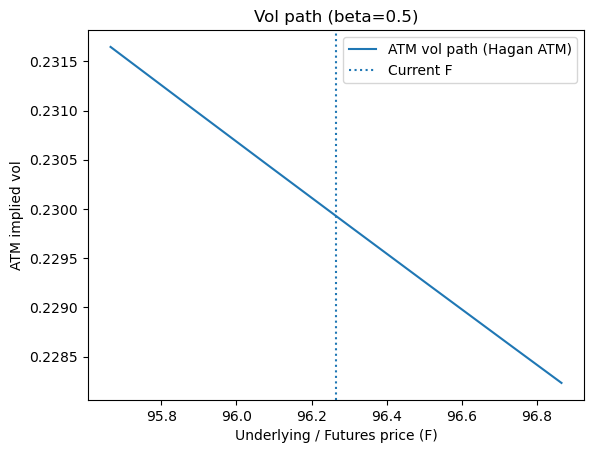

min: 0.2282318825178566
max: 0.23164625446297432
range: 0.0034143719451177335


In [60]:
# 5.1 — Vol path ONLY: SABR-implied ATM vol as F moves (set K = F)
# Uses Hagan ATM formula (since vs.sabr is constant at ATM in your setup)

beta = 0.5
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

# grid of hypothetical underlying values (use your strike range or just around F)
F_grid = np.linspace(F - 0.6, F + 0.6, 200)

omb = 1.0 - beta
term1 = (omb**2 / 24.0) * (alpha**2) / (F_grid ** (2.0 * omb))
term2 = (rho * beta * nu * alpha) / (4.0 * (F_grid ** omb))
term3 = (2.0 - 3.0 * rho**2) * (nu**2) / 24.0

atm_vol_path = (alpha / (F_grid ** omb)) * (1.0 + (term1 + term2 + term3) * T)

plt.figure()
plt.plot(F_grid, atm_vol_path, label="ATM vol path (Hagan ATM)")
plt.axvline(F, linestyle=":", label="Current F")
plt.xlabel("Underlying / Futures price (F)")
plt.ylabel("ATM implied vol")
plt.title(f"Vol path (beta={beta})")
plt.legend()
plt.show()

print("min:", float(atm_vol_path.min()))
print("max:", float(atm_vol_path.max()))
print("range:", float(atm_vol_path.max() - atm_vol_path.min()))

## 5.2.

Using the vol path, compute $\frac{\partial \sigma_{\text{ATM}}}{\partial F}$ for the same 50bp shock as Section 4.

Decompose the total fixed-strike vol change into two channels:

| Channel | Description |
|---------|-------------|
| **Vol-level** (backbone) | How much ATM vol itself changes: $\frac{\partial \sigma_{\text{ATM}}}{\partial F}$ |
| **Moneyness** (residual) | The remainder: $\frac{\partial \sigma}{\partial F}\bigg|_{\text{fixed }K} - \frac{\partial \sigma_{\text{ATM}}}{\partial F}$ |

Report the share of the total delta correction attributable to each channel.


In [61]:
# 5.2 — Decompose dσ/dF into vol-level (ATM path) + moneyness (residual)
# No new imports. Assumes you already have: F, K_atm (fixed strike from Sec 4), T, vs, results, beta.

beta = 0.5
alpha = results[beta]["alpha"]
nu    = results[beta]["nu"]
rho   = results[beta]["rho"]

dF = -0.50
F0 = float(F)
F1 = F0 + dF
K_fixed = float(K_atm)

# ---- Total fixed-strike slope: dσ/dF |_{fixed K} from SABR vols ----
sig0_fixed = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F0, np.array([K_fixed]), T))[0])
sig1_fixed = float(np.asarray(vs.sabr(beta, nu, rho, alpha, F1, np.array([K_fixed]), T))[0])
dsig_dF_fixed = (sig1_fixed - sig0_fixed) / dF

# ---- Vol-level slope: dσ_ATM/dF using the ATM vol path (Hagan ATM) ----
omb = 1.0 - beta

def sabr_atm_hagan(F_):
    # Hagan ATM approximation at strike=forward
    term1 = (omb**2 / 24.0) * (alpha**2) / (F_ ** (2.0 * omb))
    term2 = (rho * beta * nu * alpha) / (4.0 * (F_ ** omb))
    term3 = (2.0 - 3.0 * rho**2) * (nu**2) / 24.0
    return (alpha / (F_ ** omb)) * (1.0 + (term1 + term2 + term3) * T)

sig0_atm = sabr_atm_hagan(F0)
sig1_atm = sabr_atm_hagan(F1)
dsig_dF_atm = (sig1_atm - sig0_atm) / dF

# ---- Moneyness (residual) channel ----
dsig_dF_resid = dsig_dF_fixed - dsig_dF_atm

# ---- Shares of the delta correction (vega cancels out) ----
den = dsig_dF_fixed if abs(dsig_dF_fixed) > 1e-14 else np.nan
share_vol_level = dsig_dF_atm / den
share_moneyness = dsig_dF_resid / den

print("=== 5.2 Vol-change decomposition for 50bp shock (dF=-0.50) ===")
print(f"Fixed strike K: {K_fixed:.6f}")
print(f"F0: {F0:.6f} -> F1: {F1:.6f}")
print()
print("SABR vols at fixed strike:")
print(f"  sigma(F0,K): {sig0_fixed:.8f}")
print(f"  sigma(F1,K): {sig1_fixed:.8f}")
print()
print("ATM vols (vol path, Hagan ATM):")
print(f"  sigma_ATM(F0): {sig0_atm:.8f}")
print(f"  sigma_ATM(F1): {sig1_atm:.8f}")
print()
print("Slopes:")
print(f"  dσ/dF | fixed K         : {dsig_dF_fixed:+.8f}")
print(f"  dσ_ATM/dF (vol-level)   : {dsig_dF_atm:+.8f}")
print(f"  residual (moneyness)    : {dsig_dF_resid:+.8f}")
print()
print("Shares of total delta correction (Δcorr = vega * dσ/dF):")
print(f"  Vol-level share   : {100*share_vol_level:6.2f}%")
print(f"  Moneyness share   : {100*share_moneyness:6.2f}%")

=== 5.2 Vol-change decomposition for 50bp shock (dF=-0.50) ===
Fixed strike K: 96.250000
F0: 96.265000 -> F1: 95.765000

SABR vols at fixed strike:
  sigma(F0,K): 0.22770223
  sigma(F1,K): 0.30163483

ATM vols (vol path, Hagan ATM):
  sigma_ATM(F0): 0.22992800
  sigma_ATM(F1): 0.23135832

Slopes:
  dσ/dF | fixed K         : -0.14786520
  dσ_ATM/dF (vol-level)   : -0.00286065
  residual (moneyness)    : -0.14500455

Shares of total delta correction (Δcorr = vega * dσ/dF):
  Vol-level share   :   1.93%
  Moneyness share   :  98.07%


## 5.3.

The decomposition above is specific to the SABR model with stable parameters.

Under what market conditions would you expect the **vol-level channel** to dominate instead?


## ANSWER

The **vol-level channel** should dominate when the market is experiencing a **broad repricing of volatility levels** that is not primarily driven by moneyness/spot moves.

Examples:
- **Vol regime shifts / macro uncertainty** (e.g., major data surprises, central bank events, crisis periods) where implied vols rise (or fall) across strikes.
- **Large changes in risk premia** (risk-off / risk-on) that lift or depress the whole surface.
- Situations where the surface behaves more like **“sticky delta” / parallel vol shifts**, i.e., ATM vol moves strongly even if the underlying move is modest.

In contrast, when the main effect is **sliding along a stable skew** as the underlying moves (surface shape stable, ATM level relatively stable), the **moneyness (residual) channel** tends to dominate.

# 6. Cross-Asset Comparison (Optional)


## 6.1.

Fit SABR (with $\beta=0.5$) to **`TYA`** (10-Year US Treasury Note Futures).

Create a table comparing the calibrated parameters ($\alpha$, $\rho$, $\nu$) for SFRA and TYA.


## 6.2.

Which asset shows the stronger skew (more negative $\rho$)?
Which shows more smile curvature (higher $\nu$)?

Do these differences align with your intuition about these markets?
